# Week 6 Final: Baseline Models for Emergency Triage

**Student:** Terry Benjamin Jr.  
**Programme:** CariSurg MedTech Pathways  
**Submission:** Week 6 final

I am testing whether simple, reproducible classifiers can predict the Emergency Severity Index (ESI) level recorded at triage. The notebook follows the Week 6 workflow: a stratified 80/20 split, a stratified dummy baseline, logistic regression with scaled inputs, and a shallow decision tree. The main safety measure is recall for ESI 1 because missing a patient who needs immediate intervention is the highest-consequence error.

The models are exploratory decision-support baselines. They are not suitable for clinical use.

## 1. Setup and reproducibility

The split and each stochastic model use the same committed seed. This keeps the results reproducible across runs.

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]

working_directory = Path.cwd()
repo_root = working_directory.parent if working_directory.name == "notebooks" else working_directory
docs_directory = repo_root / "docs"

print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"random seed {RANDOM_STATE}")

pandas 2.3.3
numpy 2.0.2
scikit-learn 1.6.1
random seed 42


## 2. Load and verify the Week 5 dataset

The full programme CSV is intentionally not stored in GitHub. Set CARISURG_TRIAGE_CSV to its local path before running this notebook. The fallback paths support a local data folder or a file uploaded beside the notebook.

In [2]:
candidate_paths = [
    os.getenv("CARISURG_TRIAGE_CSV"),
    repo_root / "data" / "yaleemmlc_admissionprediction_triage.csv",
    repo_root / "week5" / "data" / "yaleemmlc_admissionprediction_triage.csv",
    working_directory / "yaleemmlc_admissionprediction_triage.csv",
]

data_path = next(
    (Path(path).expanduser() for path in candidate_paths if path and Path(path).expanduser().exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError(
        "Set CARISURG_TRIAGE_CSV to the full Week 5 triage CSV before running this notebook."
    )

triage = pd.read_csv(data_path)
triage = triage.drop(columns=["Unnamed: 0"], errors="ignore")

assert "esi" in triage.columns
assert set(triage["esi"].dropna().unique()) == {1, 2, 3, 4, 5}
duplicate_rows = int(triage.duplicated().sum())
assert duplicate_rows == 0

print(f"Loaded {triage.shape[0]:,} visits and {triage.shape[1]} columns.")
pd.DataFrame(
    {
        "check": ["visits", "columns", "missing cells", "duplicate rows"],
        "value": [
            triage.shape[0],
            triage.shape[1],
            int(triage.isna().sum().sum()),
            duplicate_rows,
        ],
    }
).set_index("check")

Loaded 55,121 visits and 225 columns.


,value
check,
visits,55121
columns,225
missing cells,0
duplicate rows,0


## 3. Target distribution and feature rules

ESI 1 is rare, so a random split could put too few critical cases in the test set. I stratify on esi to preserve the class mix.

For this first baseline I exclude:

- disposition and previousdispo, which are known after triage and would leak future information;
- string fields that have not yet been encoded, including categorical demographic and arrival fields.

The remaining numeric inputs include age, front-door vital signs, and chief-complaint flags, matching the live Tutorial 2 implementation. Categorical demographic fields remain out of the first baseline and would need both encoding and a fairness review before use.

In [3]:
target = "esi"

leakage_columns = ["disposition", "previousdispo"]

non_numeric_columns = triage.select_dtypes(exclude="number").columns.tolist()
excluded = set([target] + leakage_columns + non_numeric_columns)
feature_columns = [
    column
    for column in triage.columns
    if column not in excluded and pd.api.types.is_numeric_dtype(triage[column])
]
constant_columns = [column for column in feature_columns if triage[column].nunique() <= 1]

X = triage[feature_columns].copy()
y = triage[target].astype(int)

assert X.select_dtypes(exclude="number").empty
assert np.isfinite(X.to_numpy()).all()
assert X.isna().sum().sum() == 0

class_distribution = y.value_counts().sort_index().rename_axis("ESI level").to_frame("visits")
class_distribution["share"] = class_distribution["visits"] / len(y)

print(f"Model features: {len(feature_columns)}")
print(f"Unencoded string fields held out: {len(non_numeric_columns)}")
print(f"Constant fields retained for tutorial parity: {constant_columns}")
class_distribution.style.format({"visits": "{:,}", "share": "{:.2%}"})

Model features: 209
Unencoded string fields held out: 15
Constant fields retained for tutorial parity: ['cc_cardiacarrest']


,visits,share
ESI level,,
1,77,0.14%
2,"17,924",32.52%
3,"27,010",49.00%
4,"8,896",16.14%
5,"1,214",2.20%


## 4. Stratified train/test split

Twenty per cent of the visits are held out for testing. Scaling is fitted only on the training set, then applied to the test set using the same fitted scaler.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_check = pd.concat(
    [
        y_train.value_counts(normalize=True).sort_index().rename("train share"),
        y_test.value_counts(normalize=True).sort_index().rename("test share"),
    ],
    axis=1,
)

print(f"Training visits: {len(X_train):,}")
print(f"Test visits: {len(X_test):,}")
print(f"ESI 1 cases in test set: {(y_test == 1).sum()}")
split_check.style.format("{:.2%}")

Training visits: 44,096
Test visits: 11,025
ESI 1 cases in test set: 16


,train share,test share
esi,,
1,0.14%,0.15%
2,32.52%,32.52%
3,49.00%,49.00%
4,16.14%,16.14%
5,2.20%,2.20%


## 5. Train the baselines

The dummy classifier is the floor: it guesses in the same proportions seen in the training data. Logistic regression uses standardised inputs. The decision tree uses the unscaled values and is limited to five levels so that it remains interpretable and less prone to memorising noise.

In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)
    logistic.fit(X_train_scaled, y_train)
    logistic_predictions = logistic.predict(X_test_scaled)
assert np.isfinite(logistic.coef_).all()

tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

predictions = {
    "Stratified dummy": dummy.predict(X_test),
    "Logistic regression": logistic_predictions,
    "Decision tree": tree.predict(X_test),
}

print("All three models were fitted on the same training split.")

All three models were fitted on the same training split.


## 6. Final evaluation

I report accuracy, macro F1, weighted F1, and ESI 1 recall. Weighted F1 gives more influence to common classes such as ESI 3. Macro F1 gives each ESI level equal weight. The primary safety measure is ESI 1 recall.

In [6]:
def summarise_model(name, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "esi_1_recall": recall_score(
            y_test, y_pred, labels=[1], average=None, zero_division=0
        )[0],
    }

metrics = pd.DataFrame(
    [summarise_model(name, y_pred) for name, y_pred in predictions.items()]
).set_index("model")

metrics_path = docs_directory / "w6_final_metrics.csv"
metrics_path.parent.mkdir(exist_ok=True)
metrics.to_csv(metrics_path)

metrics.style.format("{:.3f}").highlight_max(axis=0, color="#e7efe7")

,accuracy,macro_f1,weighted_f1,esi_1_recall
model,,,,
Stratified dummy,0.375,0.204,0.375,0.000
Logistic regression,0.683,0.508,0.677,0.250
Decision tree,0.547,0.207,0.448,0.000


In [7]:
per_class_rows = []
for model_name in ["Logistic regression", "Decision tree"]:
    report = classification_report(
        y_test,
        predictions[model_name],
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    for label in LABELS:
        result = report[str(label)]
        per_class_rows.append(
            {
                "model": model_name,
                "esi_level": label,
                "precision": result["precision"],
                "recall": result["recall"],
                "f1_score": result["f1-score"],
                "support": int(result["support"]),
            }
        )

per_class_metrics = pd.DataFrame(per_class_rows)
per_class_metrics.to_csv(docs_directory / "w6_per_class_metrics.csv", index=False)

per_class_metrics.style.format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1_score": "{:.3f}", "support": "{:,}"}
).hide(axis="index")


model,esi_level,precision,recall,f1_score,support
Logistic regression,1,0.500,0.250,0.333,16
Logistic regression,2,0.736,0.626,0.677,"3,585"
Logistic regression,3,0.676,0.770,0.720,"5,402"
Logistic regression,4,0.622,0.612,0.617,"1,779"
Logistic regression,5,0.500,0.119,0.193,243
Decision tree,1,0.000,0.000,0.000,16
Decision tree,2,0.790,0.233,0.360,"3,585"
Decision tree,3,0.522,0.962,0.677,"5,402"
Decision tree,4,0.000,0.000,0.000,"1,779"
Decision tree,5,0.000,0.000,0.000,243


## 7. Final confusion-matrix artefacts

Rows are the true ESI level and columns are the predicted level. Values on the diagonal are correct classifications. Off-diagonal values show the exact under-triage and over-triage errors hidden by a single accuracy score.

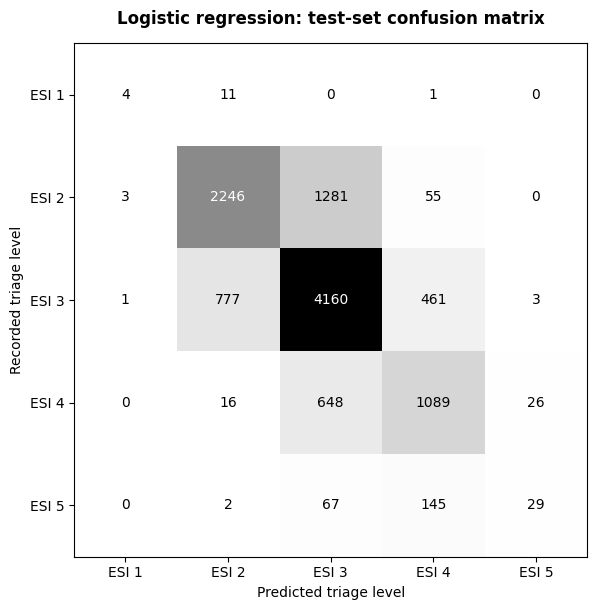

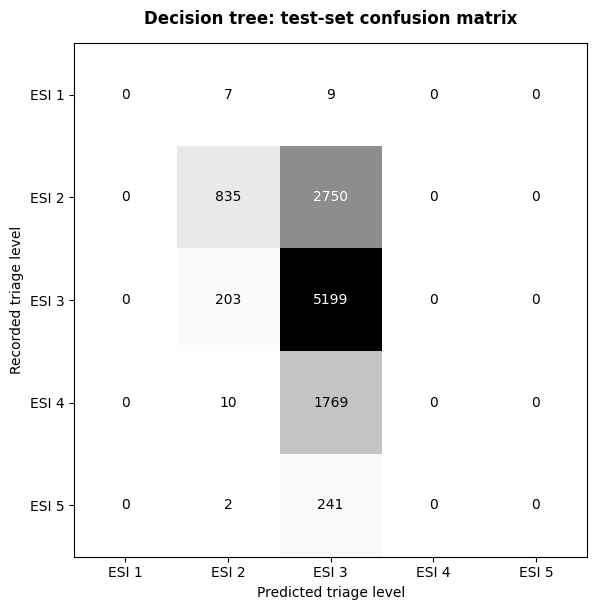

Saved docs/w6_confusion_logreg.png
Saved docs/w6_confusion_tree.png


In [8]:
def save_confusion_matrix(y_pred, title, output_name):
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=LABELS,
        display_labels=[f"ESI {label}" for label in LABELS],
        cmap="Greys",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel("Predicted triage level")
    ax.set_ylabel("Recorded triage level")
    fig.tight_layout()

    output_path = docs_directory / output_name
    fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path


logistic_matrix_path = save_confusion_matrix(
    predictions["Logistic regression"],
    "Logistic regression: test-set confusion matrix",
    "w6_confusion_logreg.png",
)
tree_matrix_path = save_confusion_matrix(
    predictions["Decision tree"],
    "Decision tree: test-set confusion matrix",
    "w6_confusion_tree.png",
)

print(f"Saved docs/{logistic_matrix_path.name}")
print(f"Saved docs/{tree_matrix_path.name}")

## 8. Clinical reading of the baseline

Accuracy is not enough for this task. The test set contains very few ESI 1 visits, yet these are the patients for whom a miss can delay immediate resuscitation. The code below makes that failure mode explicit and compares it with the aggregate scores.

In [9]:
logistic_predictions = predictions["Logistic regression"]
logistic_matrix = confusion_matrix(y_test, logistic_predictions, labels=LABELS)

esi_1_total = int((y_test == 1).sum())
esi_1_caught = int(logistic_matrix[0, 0])
esi_1_missed = esi_1_total - esi_1_caught
most_common_missed_level = LABELS[1 + int(np.argmax(logistic_matrix[0, 1:]))]

print(f"ESI 1 cases in the test set: {esi_1_total}")
print(f"Correctly identified as ESI 1: {esi_1_caught}")
print(f"Missed as a less urgent level: {esi_1_missed}")
print(f"Most common destination for a missed ESI 1 case: ESI {most_common_missed_level}")
print()
print(
    "Logistic regression macro F1 vs weighted F1: "
    f"{metrics.loc['Logistic regression', 'macro_f1']:.3f} vs "
    f"{metrics.loc['Logistic regression', 'weighted_f1']:.3f}"
)
print(
    "Decision tree ESI 1 recall: "
    f"{metrics.loc['Decision tree', 'esi_1_recall']:.3f}"
)

ESI 1 cases in the test set: 16
Correctly identified as ESI 1: 4
Missed as a less urgent level: 12
Most common destination for a missed ESI 1 case: ESI 2

Logistic regression macro F1 vs weighted F1: 0.508 vs 0.677
Decision tree ESI 1 recall: 0.000


### Final conclusion

The weakest result is ESI 1. Logistic regression correctly identified 4 of 16 ESI 1 visits and missed 12, most often assigning them ESI 2. It still clears the stratified random baseline and outperforms the depth-5 tree on aggregate measures, but this failure prevents clinical use: a patient needing immediate intervention could be assigned a less urgent level and wait longer for care.

The gap between macro and weighted F1 also confirms that performance on common classes can make the model look safer than it is. The next experiment should examine class imbalance and threshold or weighting choices without using post-triage leakage, then compare any change against both ESI 1 recall and the extra false alarms it creates.

## 9. Final report and clinical explainer

The final report records the benchmark, the class-level results, the reason I chose ESI 1 recall, and the main clinical failure. The one-minute explainer translates the 4-of-16 result without using modelling jargon.

- [Final baseline report](../docs/week-6-baseline.pdf)
- [Clinical explainer video](../docs/week6_clinical_explainer.mp4)
- [Explainer transcript](../docs/week6_clinical_explainer_script.txt)


## Files produced

- docs/w6_final_metrics.csv
- docs/w6_per_class_metrics.csv
- docs/w6_confusion_logreg.png
- docs/w6_confusion_tree.png
- docs/week-6-baseline.md
- docs/week-6-baseline.pdf
- docs/week6_clinical_explainer.mp4
- docs/week6_clinical_explainer_script.txt

The full clinical CSV remains local and is excluded from version control.
